In [19]:
import xarray as xr
import os
import torch
import numpy as np

In [8]:
os.environ["OMP_NUM_THREADS"] = "1"
data_path = "/data/jingren/repository/dataset/HadCRUT_5/1_to_10_netcdf/HadCRUT.5.0.2.0.anomalies.1.nc"
ds = xr.open_dataset(data_path)
print(ds)

<xarray.Dataset> Size: 44MB
Dimensions:         (time: 2101, latitude: 36, longitude: 72, bnds: 2)
Coordinates:
  * time            (time) datetime64[ns] 17kB 1850-01-16T12:00:00 ... 2025-0...
  * latitude        (latitude) float64 288B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * longitude       (longitude) float64 576B -177.5 -172.5 ... 172.5 177.5
    realization     int64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (time, latitude, longitude) float64 44MB ...
    time_bnds       (time, bnds) datetime64[ns] 34kB ...
    latitude_bnds   (latitude, bnds) float64 576B ...
    longitude_bnds  (longitude, bnds) float64 1kB ...
Attributes:
    comment:      2m air temperature over land blended with sea water tempera...
    history:      Data set built at: 2025-03-07T17:07:52+00:00
    institution:  Met Office Hadley Centre / Climatic Research Unit, Universi...
    licence:      HadCRUT5 is licensed under the Open Government Licence v3.0...
    reference:   

In [9]:
temperature = ds["tas"]

In [10]:
data_path_1 = "/data/jingren/repository/dataset/HadCRUT_5/1_to_10_netcdf/HadCRUT.5.0.2.0.anomalies.3.nc"
ds_1 = xr.open_dataset(data_path_1)

In [11]:
temperature_1 = ds_1["tas"]

In [12]:
error = temperature - temperature_1

In [29]:
error = torch.tensor(np.array(error))
temperature_1 = torch.tensor(np.array(temperature_1))

In [36]:
print(error[2000, 15, 33])
print(temperature_1[2100, 20, 60])

tensor(0.0199, dtype=torch.float64)
tensor(1.2506, dtype=torch.float64)


In [40]:
temp = torch.nan_to_num(temperature_1, nan=0.0)

In [41]:
temp

tensor([[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0

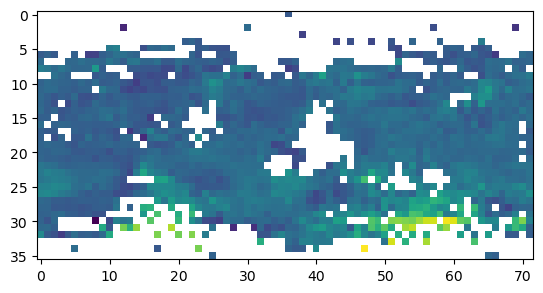

In [45]:
import matplotlib.pyplot as plt
plt.imshow(temperature_1[2098, :, :])